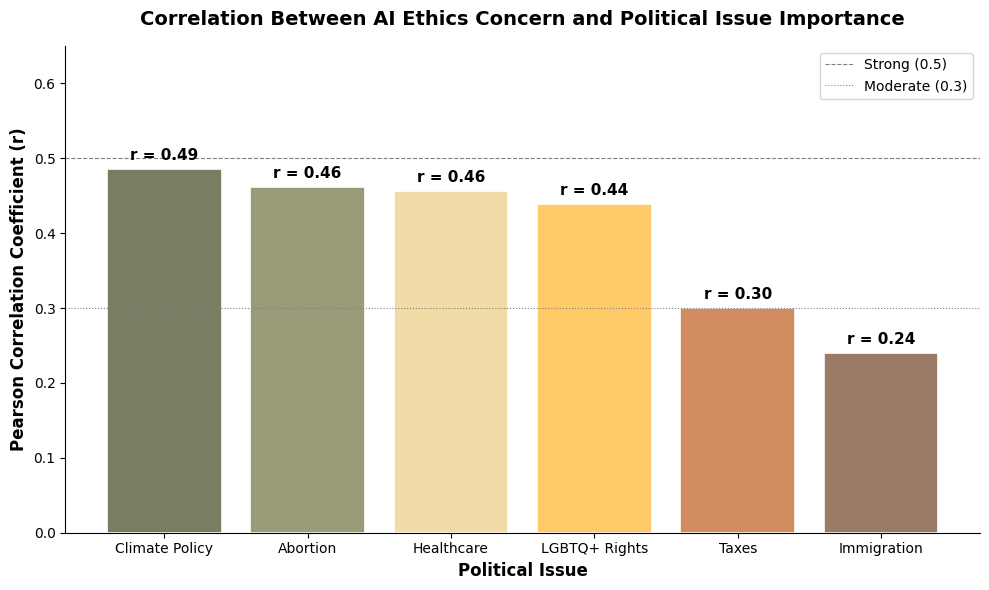

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data_cleaned_ethics_political.csv')

ethics_col = 'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, \u2026)'

political_cols = [
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Immigration]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Abortion]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [LGBTQ+ Rights]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Taxes]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Healthcare]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Climate Policy]',
]

political_short = ['Immigration', 'Abortion', 'LGBTQ+ Rights', 'Taxes', 'Healthcare', 'Climate Policy']

corr_values = {label: df[ethics_col].corr(df[col]) for col, label in zip(political_cols, political_short)}
corr_series = pd.Series(corr_values).sort_values(ascending=False)

colors = ['#797D62', '#9B9B7A', '#F1DCA7', '#FFCB69', '#D08C60', '#997B66']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(corr_series.index, corr_series.values, color=colors, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, corr_series.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.008, f'r = {val:.2f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, label='Strong (0.5)')
ax.axhline(y=0.3, color='gray', linestyle=':', linewidth=0.8, label='Moderate (0.3)')

ax.set_ylim(0, 0.65)
ax.set_xlabel('Political Issue', fontsize=12, fontweight='bold')
ax.set_ylabel('Pearson Correlation Coefficient (r)', fontsize=12, fontweight='bold')
ax.set_title('Correlation Between AI Ethics Concern and Political Issue Importance', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('barchart_ethics_vs_political.png', dpi=300, bbox_inches='tight')
plt.show()

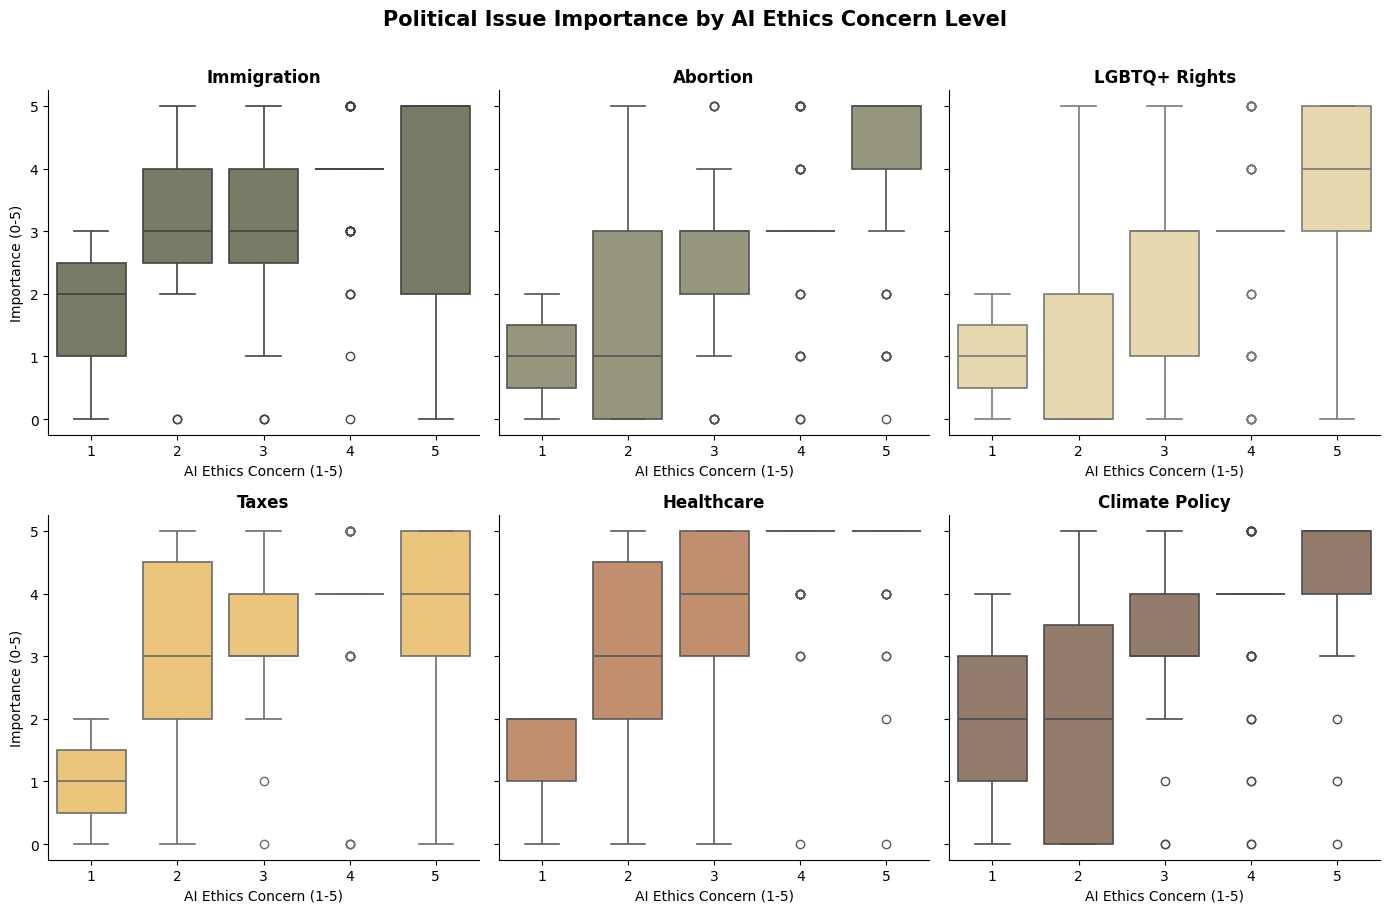

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data_cleaned_ethics_political.csv')

ethics_col = 'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, \u2026)'

political_cols = [
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Immigration]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Abortion]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [LGBTQ+ Rights]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Taxes]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Healthcare]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Climate Policy]',
]

political_short = ['Immigration', 'Abortion', 'LGBTQ+ Rights', 'Taxes', 'Healthcare', 'Climate Policy']
colors = ['#797D62', '#9B9B7A', '#F1DCA7', '#FFCB69', '#D08C60', '#997B66']

fig, axes = plt.subplots(2, 3, figsize=(14, 9), sharey=True)
axes = axes.flatten()

for i, (col, label, color) in enumerate(zip(political_cols, political_short, colors)):
    sns.boxplot(data=df, x=ethics_col, y=col, ax=axes[i], color=color, linewidth=1.2)
    axes[i].set_title(label, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('AI Ethics Concern (1-5)', fontsize=10)
    axes[i].set_ylabel('Importance (0-5)' if i % 3 == 0 else '', fontsize=10)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

fig.suptitle('Political Issue Importance by AI Ethics Concern Level', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplot_grid_ethics_vs_political.png', dpi=300, bbox_inches='tight')
plt.show()

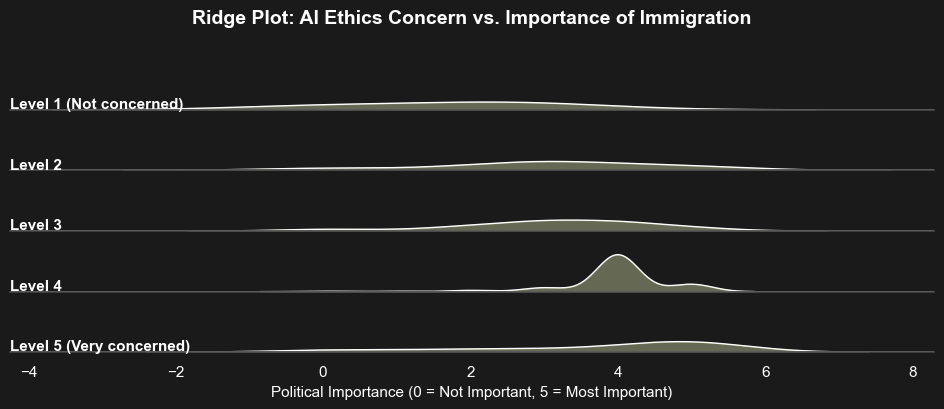

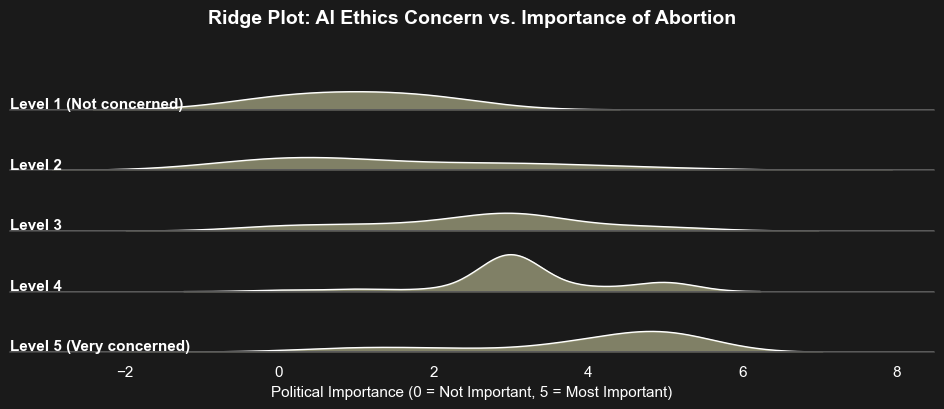

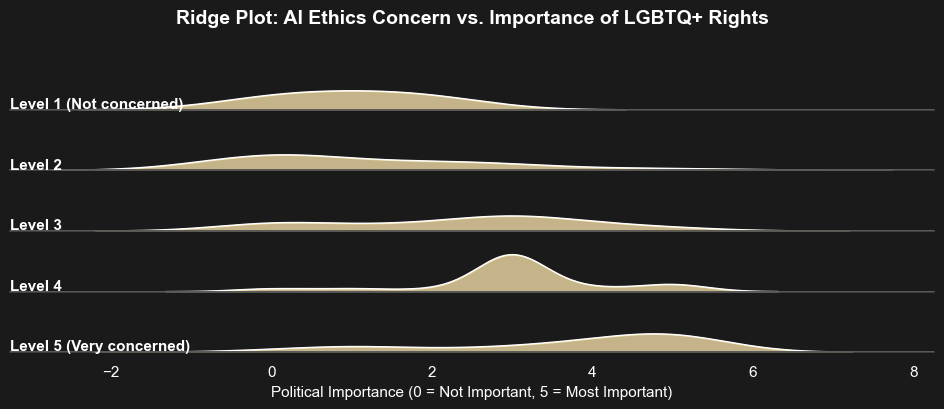

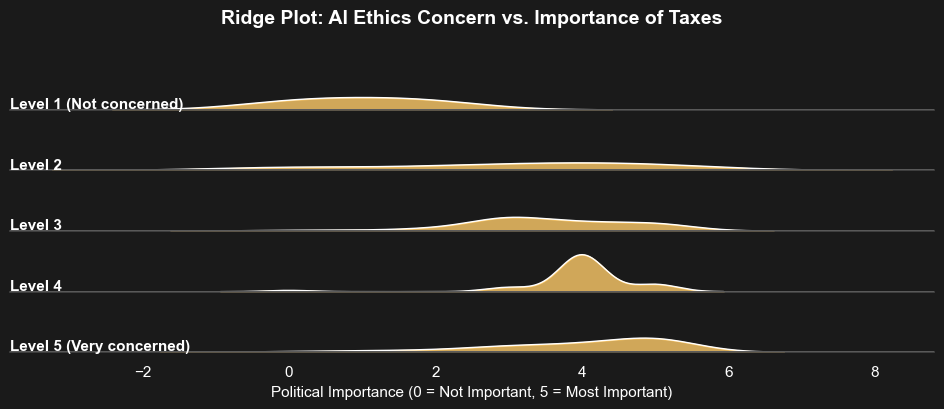

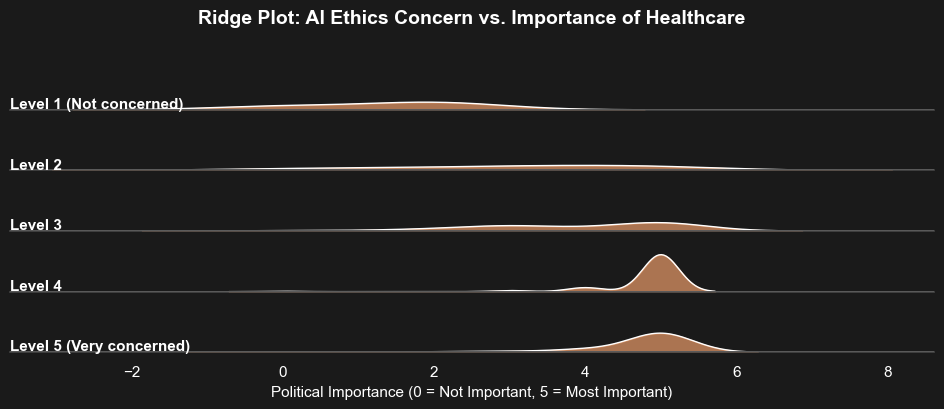

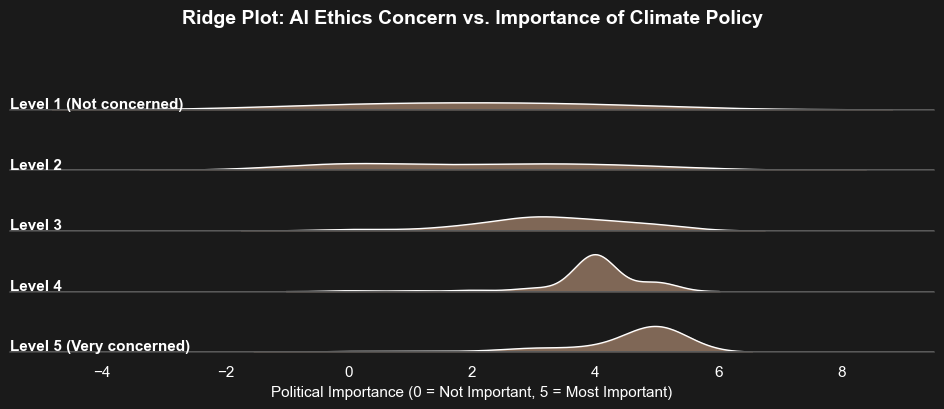

In [19]:
ethics_col = 'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, …)'

political_cols = {
    'Immigration':   'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Immigration]',
    'Abortion':      'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Abortion]',
    'LGBTQ+ Rights': 'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [LGBTQ+ Rights]',
    'Taxes':         'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Taxes]',
    'Healthcare':    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Healthcare]',
    'Climate Policy':'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Climate Policy]',
}

issue_colors = {
    'Immigration':   '#797D62',
    'Abortion':      '#9B9B7A',
    'LGBTQ+ Rights': '#F1DCA7',
    'Taxes':         '#FFCB69',
    'Healthcare':    '#D08C60',
    'Climate Policy':'#997B66',
}

ethics_labels = {
    1: 'Level 1 (Not concerned)',
    2: 'Level 2',
    3: 'Level 3',
    4: 'Level 4',
    5: 'Level 5 (Very concerned)',
}

ethics_order = list(ethics_labels.values())

rows = []
for label, col in political_cols.items():
    sub = df[[ethics_col, col]].dropna().copy()
    sub.columns = ['Ethics Concern', 'Political Importance']
    sub['Political Issue'] = label
    sub['Ethics Level'] = sub['Ethics Concern'].map(ethics_labels)
    rows.append(sub)

long_df = pd.concat(rows, ignore_index=True)
issues = list(political_cols.keys())

for issue in issues:
    issue_df = long_df[long_df['Political Issue'] == issue].copy()

    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

    g = sns.FacetGrid(
        issue_df,
        row="Ethics Level",
        hue="Ethics Level",
        aspect=12,
        height=0.8,
        palette=[issue_colors[issue]] * len(ethics_order),
        row_order=ethics_order,
        hue_order=ethics_order,
    )

    g.map(sns.kdeplot, "Political Importance", fill=True, alpha=0.8)
    g.map(sns.kdeplot, "Political Importance", color="white", linewidth=1)
    g.map(plt.axhline, y=0, linewidth=2, color="white")

    def label_ridge(x, color, label):
        ax = plt.gca()
        ax.text(0, 0.15, label, fontweight="bold", color="white",
                ha="left", va="center", transform=ax.transAxes, fontsize=11)

    g.map(label_ridge, "Political Importance")

    g.fig.patch.set_facecolor('#1a1a1a')
    for ax in g.axes.flat:
        ax.set_facecolor('#1a1a1a')
        ax.tick_params(colors='white')
        ax.xaxis.label.set_color('white')
        for spine in ax.spines.values():
            spine.set_edgecolor('#444444')

    g.fig.suptitle(
        f"Ridge Plot: AI Ethics Concern vs. Importance of {issue}",
        fontsize=14, fontweight='bold', y=1.02, color='white'
    )
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.set_xlabels("Political Importance (0 = Not Important, 5 = Most Important)", fontsize=11)
    g.despine(left=True)

    plt.tight_layout()
    plt.show()